In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

## Roadmap

1. Load an edm4hep file
2. Load the particles and tracker hits
3. Inspect Higgs-portal truth particles (e.g. PDG 35/36 and the displaced b-jets from 36 → b b̄)


## Loading

In [22]:
# Load the edm4hep file with uproot
edm_input_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/higgs_portal/v1/runs/0/edm4hep.root"
event = EDM4hepEventBatch(edm_input_file, events=(0, 9), condense_calo=False, full_load=True)


In [23]:
tracker_hits = event.get_tracker_hits_df()
calo_hits = event.get_calo_hits_df()
particles = event.get_particles_df()
daughters = event.get_daughters_df()
parents = event.get_parents_df()

In [15]:
particles.PDG.unique()

array([      2212,         21,       2101,          2,        213,
             -211,        111,        211,       2114,      -2112,
            -2212,        113,       2112,         -2,       -213,
              223,        221,         -1,          1,        311,
             -311,        323,       -321,       2214,      -2114,
               22,        130,         35,        331,      -2224,
              321,       -313,        310,         36,          5,
               -5,       -531,        523,        431,       -411,
              521,       -513,         11,        -12,       -423,
             2224,       -511,       -421,        -14,         13,
              413,        411,      20213,        -11, 1000140280,
              -13, 1000010020, 1000020030, 1000010030,         14,
             3322,       3122, 1000120250], dtype=int32)

In [16]:
particles.columns

Index(['event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time',
       'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin',
       'parents_end', 'generatorStatus', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'daughters_begin', 'daughters_end', 'vr', 'endpoint_r',
       'energy', 'kinetic_energy', 'particle_id', 'created_in_simulation',
       'num_tracker_hits', 'num_calo_hits'],
      dtype='object')

In [17]:
particles[particles.PDG == 36]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,daughters_begin,daughters_end,vr,endpoint_r,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
384,0,384,36,0,0.0,0.209118,55.0,-0.020831,-0.030924,-65.98809,...,1315,1317,0.037286,3.059550,84.504500,29.504500,384,False,0,0
385,0,385,36,0,0.0,0.209118,55.0,-0.020831,-0.030924,-65.98809,...,1317,1319,0.037286,103.875347,66.844952,11.844952,385,False,0,0


In [18]:
daughters.iloc[1315:1317]

,event_id,subentry,particle_id,collectionID
1315,0,1315,386,2714477136
1316,0,1316,387,2714477136


In [20]:
daughters.iloc[1317:1319]

,event_id,subentry,particle_id,collectionID
1317,0,1317,388,2714477136
1318,0,1318,389,2714477136


In [19]:
particles.iloc[386:388]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,daughters_begin,daughters_end,vr,endpoint_r,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
386,0,386,5,0,-0.333333,0.224956,4.8,-0.349017,-3.039578,-64.029819,...,1319,1320,3.05955,3.05955,51.694807,46.894807,386,False,0,0
387,0,387,-5,0,0.333333,0.224956,4.8,-0.349017,-3.039578,-64.029819,...,1320,1322,3.05955,3.05955,32.809693,28.009693,387,False,0,0


In [21]:
particles.iloc[388:390]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,daughters_begin,daughters_end,vr,endpoint_r,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
388,0,388,5,0,-0.333333,0.850758,4.8,97.865932,-34.818774,-31.934521,...,1322,1324,103.875347,103.875347,46.379736,41.579736,388,False,0,0
389,0,389,-5,0,0.333333,0.850758,4.8,97.865932,-34.818774,-31.934521,...,1324,1325,103.875347,103.875347,20.465216,15.665216,389,False,0,0


In [24]:
daughters

,event_id,subentry,particle_id,collectionID
0,0,0,1,2714477136
1,0,1,2,2714477136
2,0,2,3,2714477136
3,0,3,8,2714477136
4,0,4,9,2714477136
...,...,...,...,...
70048,7,13449,8447,2714477136
70049,7,13450,8454,2714477136
70050,7,13451,8458,2714477136
70051,7,13452,8459,2714477136


In [26]:
event_particles = particles[particles.event_id == 2]

In [27]:
event_daughters = daughters[daughters.event_id == 2]

In [28]:
event_particles[event_particles.PDG == 36]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,daughters_begin,daughters_end,vr,endpoint_r,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
8000,2,1549,36,0,0.0,-0.248119,55.0,0.002833,-0.009228,59.477153,...,6508,6510,0.009653,50.244889,62.581592,7.581592,1549,False,0,0
8001,2,1550,36,0,0.0,-0.248119,55.0,0.002833,-0.009228,59.477153,...,6510,6512,0.009653,77.393477,66.979673,11.979673,1550,False,0,0


In [30]:
event_daughters.iloc[6508:6510]

,event_id,subentry,particle_id,collectionID
15751,2,6508,1551,2714477136
15752,2,6509,1552,2714477136


In [31]:
event_particles.iloc[1551:1553]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,daughters_begin,daughters_end,vr,endpoint_r,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
8002,2,1551,5,0,-0.333333,0.137928,4.8,49.497642,-8.633212,36.571257,...,6512,6513,50.244889,50.244889,23.856018,19.056018,1551,False,0,0
8003,2,1552,-5,0,0.333333,0.137928,4.8,49.497642,-8.633212,36.571257,...,6513,6515,50.244889,50.244889,38.725574,33.925574,1552,False,0,0


In [32]:
a_particles = particles[particles.PDG == 36].copy()

# IMPORTANT: daughters_begin/end are per-event offsets, so slice daughters within each event
rows = []
for a in a_particles.itertuples(index=False):
    dau_event = daughters[daughters.event_id == a.event_id].reset_index(drop=True)
    dau_slice = dau_event.iloc[int(a.daughters_begin):int(a.daughters_end)]
    dau_ids = dau_slice["particle_id"].to_list()

    particles_event = particles[particles.event_id == a.event_id]
    dau_particles = particles_event[particles_event.particle_id.isin(dau_ids)].copy()

    for d in dau_particles.itertuples(index=False):
        rows.append({
            "event_id": a.event_id,
            "a_particle_id": a.particle_id,
            "a_vx": a.vx,
            "a_vy": a.vy,
            "a_vz": a.vz,
            "a_endpoint_x": a.endpoint_x,
            "a_endpoint_y": a.endpoint_y,
            "a_endpoint_z": a.endpoint_z,
            "a_vr": a.vr,
            "a_endpoint_r": a.endpoint_r,
            "daughter_particle_id": d.particle_id,
            "daughter_PDG": d.PDG,
            "daughter_vx": d.vx,
            "daughter_vy": d.vy,
            "daughter_vz": d.vz,
        })

children_vtx = pd.DataFrame(rows)
children_vtx.sort_values(["event_id", "a_particle_id", "daughter_particle_id"], inplace=True)
children_vtx

,event_id,a_particle_id,a_vx,a_vy,a_vz,a_endpoint_x,a_endpoint_y,a_endpoint_z,a_vr,a_endpoint_r,daughter_particle_id,daughter_PDG,daughter_vx,daughter_vy,daughter_vz
0,0,384,-0.020831,-0.030924,-65.988090,-0.349017,-3.039578,-64.029819,0.037286,3.059550,386,5,-0.349017,-3.039578,-64.029819
1,0,384,-0.020831,-0.030924,-65.988090,-0.349017,-3.039578,-64.029819,0.037286,3.059550,387,-5,-0.349017,-3.039578,-64.029819
2,0,385,-0.020831,-0.030924,-65.988090,97.865932,-34.818774,-31.934521,0.037286,103.875347,388,5,97.865932,-34.818774,-31.934521
3,0,385,-0.020831,-0.030924,-65.988090,97.865932,-34.818774,-31.934521,0.037286,103.875347,389,-5,97.865932,-34.818774,-31.934521
4,1,1057,-0.000727,-0.023050,-112.986232,-1.363289,1.020622,-120.831292,0.023061,1.703005,1059,5,-1.363289,1.020622,-120.831292
5,1,1057,-0.000727,-0.023050,-112.986232,-1.363289,1.020622,-120.831292,0.023061,1.703005,1060,-5,-1.363289,1.020622,-120.831292
6,1,1058,-0.000727,-0.023050,-112.986232,-0.000518,-0.048904,-113.012336,0.023061,0.048907,1061,5,-0.000518,-0.048904,-113.012336
7,1,1058,-0.000727,-0.023050,-112.986232,-0.000518,-0.048904,-113.012336,0.023061,0.048907,1062,-5,-0.000518,-0.048904,-113.012336
8,2,1549,0.002833,-0.009228,59.477153,49.497642,-8.633212,36.571257,0.009653,50.244889,1551,5,49.497642,-8.633212,36.571257
9,2,1549,0.002833,-0.009228,59.477153,49.497642,-8.633212,36.571257,0.009653,50.244889,1552,-5,49.497642,-8.633212,36.571257


<Axes: ylabel='Count'>

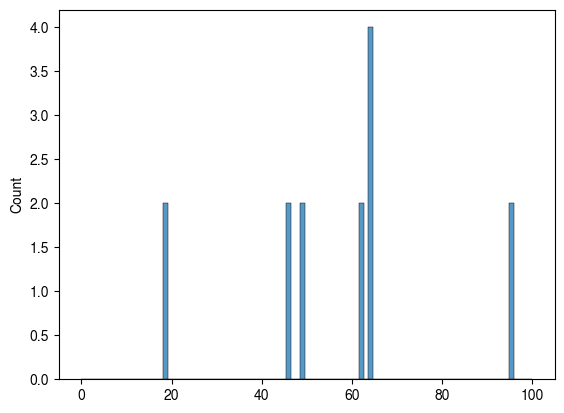

In [34]:
children_radius = np.sqrt(children_vtx.daughter_vx**2 + children_vtx.daughter_vy**2 + children_vtx.daughter_vz**2)

sns.histplot(children_radius, bins=np.linspace(0, 100, 100))

In [ ]:
tracker_hits

,event_id,subentry,cellID,time,x,y,z,detector,particle_id,r,R,phi,theta,eta
0,0,0,60077547270377222,0.144050,30.402032,-9.939022,2.208908,PixelBarrelReadout,335,31.985429,32.061612,-0.315967,1.501846,0.069005
1,0,1,6649970879241750,0.292478,63.335321,-24.882639,-17.336838,PixelBarrelReadout,335,68.047840,70.221610,-0.374346,1.820263,-0.252096
2,0,2,70070007727796262,0.481834,102.399987,-49.665924,-41.886809,PixelBarrelReadout,335,113.808881,121.272281,-0.451591,1.923456,-0.360205
3,0,3,59497099620140854,0.716374,145.373103,-87.735785,-71.972332,PixelBarrelReadout,335,169.796664,184.420507,-0.543005,1.971713,-0.412109
4,0,4,6122261132484118,0.302634,63.569908,-24.275881,-18.914919,PixelBarrelReadout,1783,68.047422,70.627373,-0.364786,1.841919,-0.274506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6375,0,654,15663745823054,9.288465,-1020.603412,66.962789,2604.500000,LongStripEndcapReadout,1759,1022.797800,2798.130731,3.076076,0.374201,1.664344
6376,0,655,15685221708110,9.306403,-1022.580861,66.846928,2609.500000,LongStripEndcapReadout,1759,1024.763450,2803.503233,3.076315,0.374202,1.664342
6377,0,656,15706696548686,9.345511,-1026.930085,66.588938,2620.500000,LongStripEndcapReadout,1759,1029.086724,2815.322315,3.076841,0.374203,1.664339
6378,0,657,15668040794446,9.363808,-1028.907160,66.468849,2625.500000,LongStripEndcapReadout,1759,1031.051915,2820.694649,3.077081,0.374203,1.664338


## Sanity checks (Higgs portal truth)

These checks assume the intended truth chain is **`PDG==35` → `PDG==36` + `PDG==36` → `b b̄` + `b b̄`** with a displaced decay for `PDG==36`.

In [35]:
import numpy as np
import pandas as pd


def _event_slice(df: pd.DataFrame, event_id: int) -> pd.DataFrame:
    """Filter a dataframe to a single `event_id`.

    Inputs:
        df: DataFrame with an `event_id` column.
        event_id: Event id to select.

    Outputs:
        A filtered copy of `df` containing only rows with `event_id`.
    """
    return df[df["event_id"] == event_id].copy()


def _daughter_ids_for_parent(
    particles_df_event: pd.DataFrame,
    daughters_df_event: pd.DataFrame,
    parent_row,
) -> list[int]:
    """Get the daughter `particle_id` list for a single parent row.

    Notes:
        - `daughters_begin/end` are **per-event offsets** into the per-event daughters link table.

    Inputs:
        particles_df_event: Particles filtered to a single event (must include `particle_id`).
        daughters_df_event: Daughters link table filtered to the same event.
        parent_row: A row-like object with `daughters_begin` and `daughters_end`.

    Outputs:
        List of daughter particle ids (ints). Empty list if range is unset/empty.
    """
    b = int(getattr(parent_row, "daughters_begin"))
    e = int(getattr(parent_row, "daughters_end"))
    if e <= b:
        return []

    d_ev = daughters_df_event.reset_index(drop=True)
    return d_ev.iloc[b:e]["particle_id"].astype(int).to_list()


def summarize_higgs_portal_chain(
    particles_df: pd.DataFrame,
    daughters_df: pd.DataFrame,
    higgs_pdg: int = 35,
    a_pdg: int = 36,
    b_pdgs: tuple[int, int] = (5, -5),
) -> pd.DataFrame:
    """Summarize the truth-chain structure per event.

    Inputs:
        particles_df: Full particles dataframe (must include `event_id`, `PDG`, `particle_id`, `daughters_begin/end`).
        daughters_df: Full daughters link dataframe (must include `event_id`, `particle_id`).
        higgs_pdg: PDG id for the parent Higgs-like state.
        a_pdg: PDG id for the LLP pseudoscalar.
        b_pdgs: Expected PDGs of the LLP daughters.

    Outputs:
        DataFrame with one row per event and boolean/summary columns.
    """
    event_ids = sorted(particles_df["event_id"].unique().astype(int).tolist())
    rows: list[dict] = []

    for eid in event_ids:
        p_ev = _event_slice(particles_df, eid).reset_index(drop=True)
        d_ev = _event_slice(daughters_df, eid)

        n35 = int((p_ev["PDG"] == higgs_pdg).sum())
        n36 = int((p_ev["PDG"] == a_pdg).sum())

        higgs_has_two_a = False
        for h in p_ev[p_ev["PDG"] == higgs_pdg].itertuples(index=False):
            dau_ids = _daughter_ids_for_parent(p_ev, d_ev, h)
            dau_pdgs = p_ev[p_ev["particle_id"].isin(dau_ids)]["PDG"].astype(int).to_list()
            if sorted(dau_pdgs) == [a_pdg, a_pdg]:
                higgs_has_two_a = True
                break

        all_a_decay_to_bb = True
        for a in p_ev[p_ev["PDG"] == a_pdg].itertuples(index=False):
            dau_ids = _daughter_ids_for_parent(p_ev, d_ev, a)
            dau_pdgs = p_ev[p_ev["particle_id"].isin(dau_ids)]["PDG"].astype(int).to_list()
            if sorted(dau_pdgs) != sorted(list(b_pdgs)):
                all_a_decay_to_bb = False
                break

        rows.append(
            {
                "event_id": eid,
                "n35": n35,
                "n36": n36,
                "higgs_has_two_a": higgs_has_two_a,
                "all_a_decay_to_bb": all_a_decay_to_bb,
            }
        )

    return pd.DataFrame(rows).sort_values("event_id").reset_index(drop=True)


def compute_parent_flight_lengths(particles_df: pd.DataFrame, parent_pdg: int = 36) -> pd.DataFrame:
    """Compute LLP flight-length observables for a given parent PDG.

    Inputs:
        particles_df: Full particles dataframe.
        parent_pdg: PDG id for the LLP whose decay length should be measured.

    Outputs:
        DataFrame of parent particles with added columns:
            - L: 3D flight length (mm)
            - Lxy: transverse flight length (mm)
    """
    a = particles_df[particles_df["PDG"] == parent_pdg].copy()
    dx = a["endpoint_x"] - a["vx"]
    dy = a["endpoint_y"] - a["vy"]
    dz = a["endpoint_z"] - a["vz"]
    a["L"] = np.sqrt(dx**2 + dy**2 + dz**2)
    a["Lxy"] = np.sqrt(dx**2 + dy**2)
    return a


def compute_vertex_residuals(children_vtx_df: pd.DataFrame, daughter_pdgs: tuple[int, int] = (5, -5)) -> pd.DataFrame:
    """Compare daughter production vertex to parent endpoint.

    Inputs:
        children_vtx_df: DataFrame like `children_vtx` with parent endpoint columns and daughter vertex columns.
        daughter_pdgs: PDG ids of daughters to consider.

    Outputs:
        Filtered DataFrame with added columns:
            - d_endpoint_dr: 3D |v_daughter - endpoint_parent|
            - d_endpoint_drxy: transverse |vxy_daughter - endpoint_xy_parent|
    """
    df = children_vtx_df[children_vtx_df["daughter_PDG"].isin(daughter_pdgs)].copy()
    dx = df["daughter_vx"] - df["a_endpoint_x"]
    dy = df["daughter_vy"] - df["a_endpoint_y"]
    dz = df["daughter_vz"] - df["a_endpoint_z"]
    df["d_endpoint_dr"] = np.sqrt(dx**2 + dy**2 + dz**2)
    df["d_endpoint_drxy"] = np.sqrt(dx**2 + dy**2)
    return df

In [36]:
# Event-level truth-chain summary
chain_summary = summarize_higgs_portal_chain(particles, daughters)
chain_summary

print("\nPass fractions")
print("- higgs_has_two_a:", chain_summary["higgs_has_two_a"].mean())
print("- all_a_decay_to_bb:", chain_summary["all_a_decay_to_bb"].mean())

print("\nCounts per event")
print(chain_summary[["n35", "n36"]].describe())


Pass fractions
- higgs_has_two_a: 1.0
- all_a_decay_to_bb: 1.0

Counts per event
             n35  n36
count   8.000000  8.0
mean    7.625000  2.0
std     2.065879  0.0
min     5.000000  2.0
25%     6.000000  2.0
50%     7.500000  2.0
75%     8.500000  2.0
max    11.000000  2.0


Vertex residuals (mm)
       d_endpoint_dr  d_endpoint_drxy
count           32.0             32.0
mean             0.0              0.0
std              0.0              0.0
min              0.0              0.0
50%              0.0              0.0
90%              0.0              0.0
99%              0.0              0.0
max              0.0              0.0

LLP (PDG=36) flight-length summary (mm)
                L         Lxy
count   16.000000   16.000000
mean    75.762124   46.849711
std     81.873760   70.282513
min      0.036741    0.025856
50%     61.060581   11.773359
90%    123.026633  110.125096
99%    297.550555  246.923555
max    328.162555  269.963198


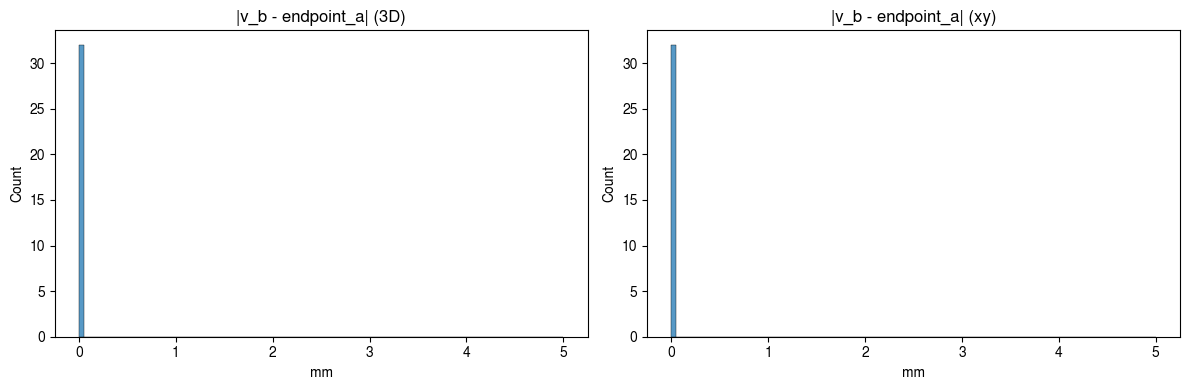

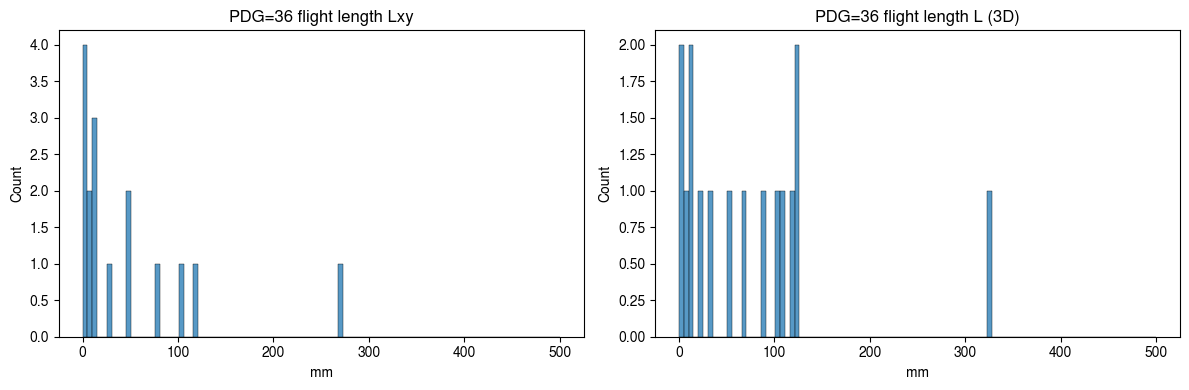

In [37]:
# Vertex-consistency: b production vertex should match a endpoint
b_resid = compute_vertex_residuals(children_vtx)

print("Vertex residuals (mm)")
print(b_resid[["d_endpoint_dr", "d_endpoint_drxy"]].describe(percentiles=[0.5, 0.9, 0.99]))

import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(b_resid["d_endpoint_dr"], bins=np.linspace(0, 5, 100), ax=ax[0])
ax[0].set_title("|v_b - endpoint_a| (3D)")
ax[0].set_xlabel("mm")

sns.histplot(b_resid["d_endpoint_drxy"], bins=np.linspace(0, 5, 100), ax=ax[1])
ax[1].set_title("|v_b - endpoint_a| (xy)")
ax[1].set_xlabel("mm")
plt.tight_layout()

# LLP flight-length: use parent (a) vertex -> endpoint, not absolute radius
parents_a = compute_parent_flight_lengths(particles, parent_pdg=36)

print("\nLLP (PDG=36) flight-length summary (mm)")
print(parents_a[["L", "Lxy"]].describe(percentiles=[0.5, 0.9, 0.99]))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(parents_a["Lxy"], bins=np.linspace(0, 500, 100), ax=ax[0])
ax[0].set_title("PDG=36 flight length Lxy")
ax[0].set_xlabel("mm")

sns.histplot(parents_a["L"], bins=np.linspace(0, 500, 100), ax=ax[1])
ax[1].set_title("PDG=36 flight length L (3D)")
ax[1].set_xlabel("mm")
plt.tight_layout()

PDG=35 mass summary (GeV)
count     61.000000
mean     125.004841
std        0.014987
min      124.989454
25%      124.997385
50%      125.000760
75%      125.002045
max      125.037223
Name: mass, dtype: float64


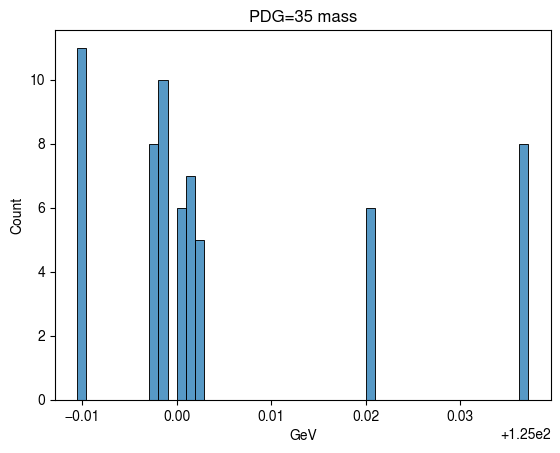

PDG=36 mass summary (GeV)
count    16.0
mean     55.0
std       0.0
min      55.0
25%      55.0
50%      55.0
75%      55.0
max      55.0
Name: mass, dtype: float64


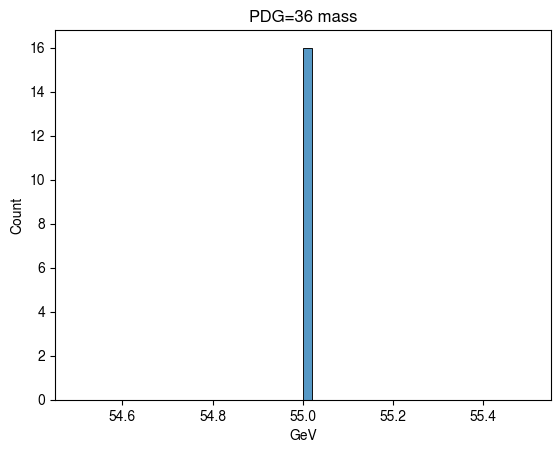

HV-like PDGs present (4900*): None

Most common PDGs


PDG
 11            12151
-11             6795
 21             5903
 22             4035
 2212           2959
-211            2572
 211            2563
 111            1378
 2112            703
 2               326
 321             230
-2               202
-13              186
 1               170
-321             166
 1000010020      143
-213             142
 13              140
 113             138
 310             134
 221             132
 223             127
 130             122
-1               117
 213             116
 311             112
-311             109
 1000140280       93
-2212             89
 5                77
Name: count, dtype: int64

In [38]:
# Quick mass + PDG sanity checks

def _mass_series(particles_df: pd.DataFrame, pdg: int) -> pd.Series:
    """Extract mass values for a given PDG.

    Inputs:
        particles_df: Full particles dataframe.
        pdg: PDG id to filter.

    Outputs:
        Pandas Series of masses (float).
    """
    return particles_df.loc[particles_df["PDG"] == pdg, "mass"].astype(float)


for pdg in (35, 36):
    m = _mass_series(particles, pdg)
    print(f"PDG={pdg} mass summary (GeV)")
    print(m.describe())
    sns.histplot(m, bins=50)
    plt.title(f"PDG={pdg} mass")
    plt.xlabel("GeV")
    plt.show()

# Flag obvious cross-contamination from other benchmarks (e.g. Hidden Valley-like PDGs)
pdg_str = particles["PDG"].astype(int).astype(str)
hv_like = particles[pdg_str.str.startswith("4900")]["PDG"].astype(int).unique()
print("HV-like PDGs present (4900*):", np.sort(hv_like) if len(hv_like) else "None")

# Quick view of the most common PDGs in this sample
print("\nMost common PDGs")
display(particles["PDG"].value_counts().head(30))

In [39]:
def count_higgs_with_two_a(particles_df, daughters_df, higgs_pdg=35, a_pdg=36, generator_only=False):
    rows = []
    for eid in sorted(particles_df["event_id"].unique().astype(int)):
        p_ev = particles_df[particles_df["event_id"] == eid].copy()
        d_ev = daughters_df[daughters_df["event_id"] == eid].copy()

        if generator_only and "created_in_simulation" in p_ev.columns:
            p_ev = p_ev[p_ev["created_in_simulation"] == False].copy()

        n35 = int((p_ev["PDG"] == higgs_pdg).sum())
        n35_to_aa = 0

        for h in p_ev[p_ev["PDG"] == higgs_pdg].itertuples(index=False):
            b = int(h.daughters_begin); e = int(h.daughters_end)
            if e <= b:
                continue
            dau_ids = d_ev.reset_index(drop=True).iloc[b:e]["particle_id"].astype(int).to_list()
            dau_pdgs = p_ev[p_ev["particle_id"].isin(dau_ids)]["PDG"].astype(int).to_list()
            if sorted(dau_pdgs) == [a_pdg, a_pdg]:
                n35_to_aa += 1

        rows.append({"event_id": eid, "n35": n35, "n35_to_aa": n35_to_aa})
    return pd.DataFrame(rows)

display(count_higgs_with_two_a(particles, daughters, generator_only=False))
display(count_higgs_with_two_a(particles, daughters, generator_only=True))

,event_id,n35,n35_to_aa
0,0,7,1
1,1,11,1
2,2,10,1
3,3,8,1
4,4,5,1
5,5,6,1
6,6,6,1
7,7,8,1


,event_id,n35,n35_to_aa
0,0,7,1
1,1,11,1
2,2,10,1
3,3,8,1
4,4,5,1
5,5,6,1
6,6,6,1
7,7,8,1
